<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/BJ/%EA%B0%84%EC%84%A0_%EC%9D%B4%EC%96%B4%EA%B0%80%EA%B8%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 간선 이어가기 2

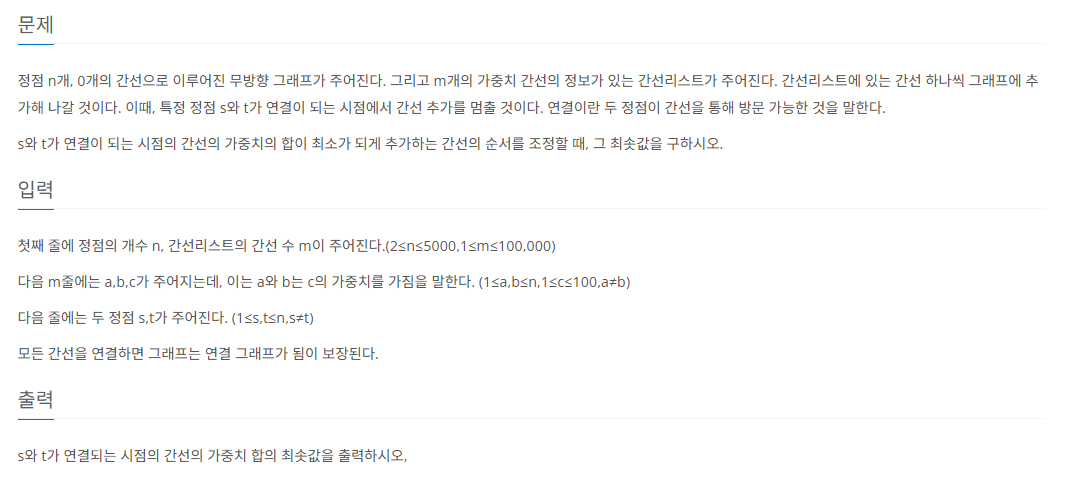

## 입력 출력 및 예제


* 입력

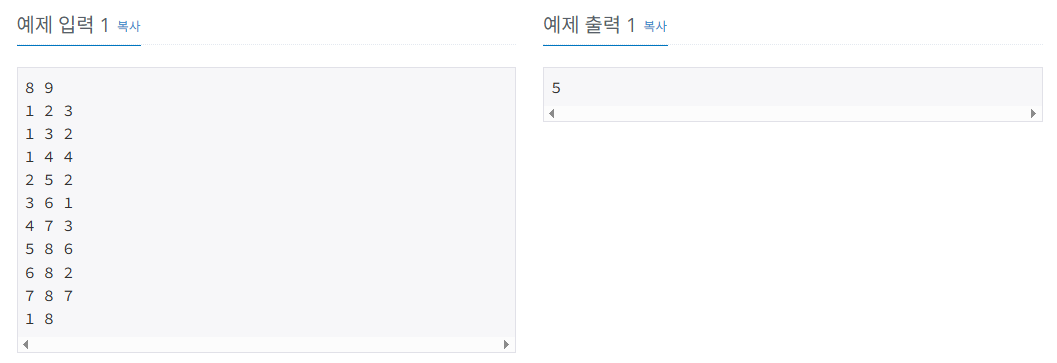

* 출력

* 예제

## 구상

-

## 코드

In [4]:
import heapq

n, m = map(int, input().split())
graph = [[] for _ in range(n+1)]

for _ in range(m):
    a, b, c = map(int, input().split())
    graph[a].append((b,c))
    graph[b].append((a,c))

s, t = map(int, input().split())

INF = float('inf')
dist = [INF] * (n + 1)
dist[s] = 0

pq = []
heapq.heappush(pq, (0, s))

while pq:
    # 잘못 생각함. 메모 참조.
    # if dist[t] != INF:
    #     print(dist[t])
    #     break

    cur_dist, now = heapq.heappop(pq)

    # 이미 해당 지점에 최소값이 있을 경우, 낭비하는 것 방지 # 이미 더 짧은 거리로 처리된 적 있으면 무시
    if cur_dist > dist[now]:
        continue

    # 내가 원했던 최적화
    if now == t:
        print(cur_dist)
        break

    for nxt, cost in graph[now]:
        new_dist = cur_dist + cost

        if new_dist < dist[nxt]:
            dist[nxt] = new_dist
            heapq.heappush(pq, (new_dist, nxt))

# while 다 돌지 않고 도중에 처리 가능. 고로 아래 코드는 안좋음
# print(dist[t])

8 9
1 2 3
1 3 2
1 4 4
2 5 2
3 6 1
4 7 3
5 8 6
6 8 2
7 8 7
1 8
5
[inf, 0, 3, 2, 4, 5, 3, inf, 5]


[1, 2, 3, 4, 6, 8, 9, 10]

### 메모



* 나는 좀 더 최적화를 위해 if dist[t] != INF: print(dist[t]) break 이 코드를 추가했는데, 조금만 생각해봐도 틀렸단걸 알수있었어. s에서 t로 가는 경로가 가장 먼저 생겼다하더라도, 그 경로가 최소값이 아닌 경우는 쉽게 찾을 수 있었어. 그러다 의문이 들었는데, 그러면 항상 다 완성 후에 s,t로 가는 최소값을 찾을수 있는건가? 우리가 힙구조를 통해 dist를 갱신해나간다한들 여전히 t로 가는 경우를 다 찾은지 아닌지 모르잖아
* ">>> t가 힙에서 pop되는 순간 끝내도 됩니다"